In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading 4F data

In [11]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_4f_all = []
fingerprints_4f_all = []
OFF_periods_4f_all = []
ON_periods_4f_all = []
intensities_4f_all = []

for _ in identifiers:
    fingerprints_4f_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    OFF_periods_4f_all.append([])
    ON_periods_4f_all.append([])
    intensities_4f_all.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\oet_variations\r100%eff001%4f"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_4f_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                non_zero = data[data > 0].values.flatten()
                non_zero = non_zero[~np.isnan(non_zero)]
                fingerprints_4f_all[identifiers.index(id)] += data.sum(axis=1)
                intensities_4f_all[identifiers.index(id)] += non_zero.tolist()
                for col in data.columns:
                    emis.event_time_series = data[col]
                    blinks = bl.Blinking(emis)
                    OFF_periods_4f_all[identifiers.index(id)] += blinks.off_periods.tolist() 
                    ON_periods_4f_all[identifiers.index(id)] += blinks.on_periods.tolist()
                break

for i, fingerprint in enumerate(fingerprints_4f_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_4f_all[i] = fingerprint

In [23]:
np.mean(intensities_4f_all[3])

np.float64(291.4759914675025)

In [14]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_2f_all = []
fingerprints_2f_all = []

for _ in identifiers:
    fingerprints_2f_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\oet_variations\r100%eff001%2f"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_2f_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_2f_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_2f_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_2f_all[i] = fingerprint

In [12]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins

OFF_periods_4f_all = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_4f_all]
log_bins_OFF_4f = get_log_bins(OFF_periods_4f_all)
weights_OFF_4f = [np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_4f_all]
ON_periods_4f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_4f_all]
log_bins_ON_4f = get_log_bins(ON_periods_4f_all)
weights_ON_4f = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_all]
intensities_4f_all = [np.array(intensities) for intensities in intensities_4f_all]
weights_intensities_4f = [np.ones_like(intensities) / len(intensities) for intensities in intensities_4f_all]

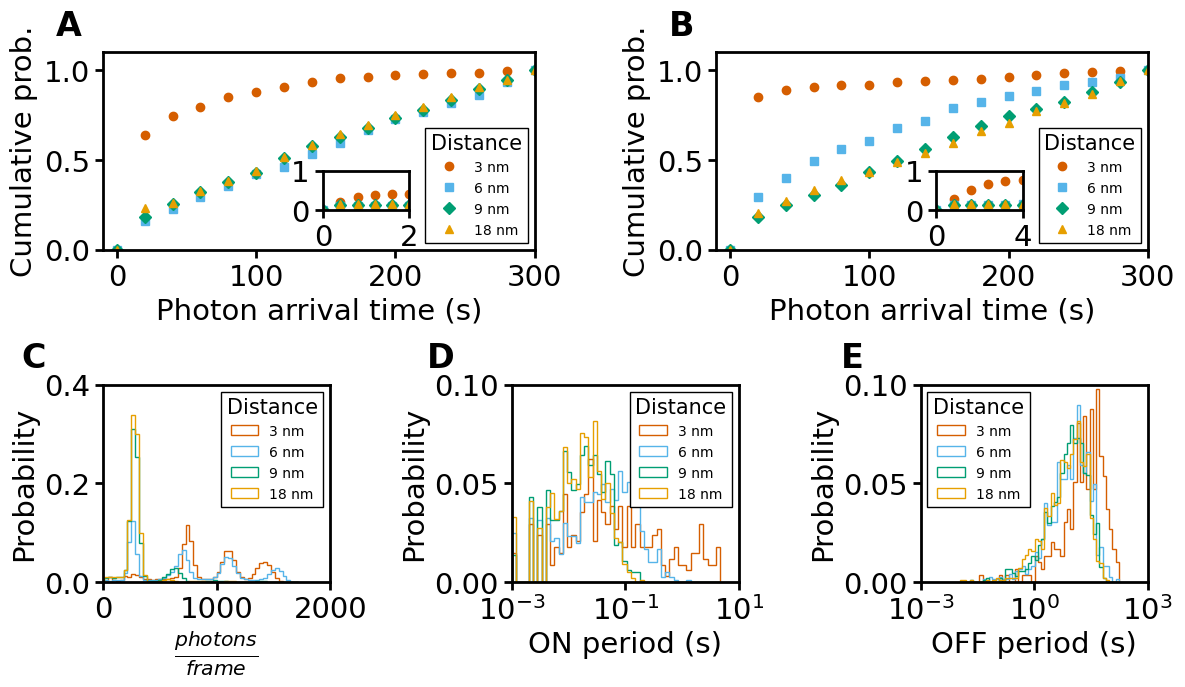

In [22]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

def plot_figure3(ax, labels, data, legendtitle, xlim2, ylim2, spacing2, inset_x_ticks,
                  colors=colors):
    markers = ['o', 's', 'D', '^']
    spacing1 = 20000
    description = dict(ylabel='Cumulative prob.', xlabel='Photon arrival time (s)', legend=True,
                        xlim=[-10, 300], ylim=[0, 1.1])
    for (fingerprint, label, color, marker) in zip(data, labels, colors, markers):
        fi.universal_figure(data=[fingerprint.index[::spacing1], fingerprint[::spacing1]], label=label, color=color, marker=marker, linestyle='', axes=ax)
    fi.universal_figure(axes=ax, legendargs=dict(title=legendtitle, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15), **description)

    inset = ax.inset_axes([0.51, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    for (fingerprint, label, color, marker) in zip(data, labels, colors, markers):
        fi.universal_figure(data=[fingerprint.index[::spacing2], fingerprint[::spacing2]], axes=inset, label=label, color=color, marker=marker, linestyle='')
    inset.set_ylabel('')
    inset.set_xlabel('')
    inset.set_xticks(inset_x_ticks)


import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['axes.linewidth'] = 2
gs = plt.GridSpec(2, 6)
fig = plt.figure(figsize=(12, 7))

ax1 = fig.add_subplot(gs[0, 0:3])
labels1 = ['3 nm', '6 nm', '9 nm', '18 nm']
legendtitle1 = 'Distance'
plot_figure3(ax1, labels1, fingerprints_2f_all, legendtitle1, 2, 1, 400, [0, 2])


ax2 = fig.add_subplot(gs[0, 3:])
plot_figure3(ax2, labels1, fingerprints_4f_all, legendtitle1, 4, 1, 800, [0, 4])

ax3 = fig.add_subplot(gs[1, 0:2])
fi.universal_figure(type_='hist', data=list(reversed(intensities_4f_all)), axes=ax3,
                    density=False, histtype='step', label=list(reversed(labels1)), alpha=1,
                    color=list(reversed(colors)), bins=50, weights=list(reversed(weights_intensities_4f)),
                    ylabel='Probability', xlabel=r'$\frac{photons}{frame}$', legend=True,
                    legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15),
                    ylim=[0, 0.4], xlim=[0, 2000])
ax4 = fig.add_subplot(gs[1, 2:4])
fi.universal_figure(type_='hist', data=list(reversed(ON_periods_4f_all)), axes=ax4,
                    density=False, histtype='step', label=list(reversed(labels1)), alpha=1,
                    color=list(reversed(colors)), bins=log_bins_ON_4f, weights=list(reversed(weights_ON_4f)),
                    xscale='log', ylabel='Probability', xlabel='ON period (s)', legend=True,
                    legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15),
                    ylim=[0, 0.1], xlim=[1e-3, 1e1])
                    
ax5 = fig.add_subplot(gs[1, 4:])
fi.universal_figure(type_='hist', data=list(reversed(OFF_periods_4f_all)), axes=ax5,
                    density=False, histtype='step', label=list(reversed(labels1)), alpha=1,
                    color=list(reversed(colors)), bins=log_bins_OFF_4f, weights=list(reversed(weights_OFF_4f)),
                    xscale='log', ylabel='Probability', xlabel='OFF period (s)', legend=True,
                    legendargs=dict(title=legendtitle1, framealpha=1, edgecolor='black', fancybox=False,
                                                 title_fontsize=15),
                    ylim=[0, 0.1], xlim=[1e-3, 1e3])

axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ['A', 'B', 'C', 'D', 'E', 'F'])):
    offset = -0.05
    if i > 1:
        offset = -0.25
    axis.text(offset, 1.05, letter, transform=axis.transAxes, fontsize=24, fontweight='bold', va='bottom', ha='right')
fig.tight_layout()
fig.savefig('fingerprint_multif.png', dpi=300, bbox_inches='tight', pad_inches=0.1)